# Project 48 — Feature Study v3 · Full Evaluation Suite (Optimised)
## Explainable Deep Learning Approach for Sleep Disorder Detection

---
### Runtime optimisations vs previous version

| What changed | Old | New | Why |
|---|---|---|---|
| Stability bootstraps | 100 | 30 | 30% threshold still meaningful at 30 runs |
| LogRegCV Cs grid | 10 | 4 | Fewer inner-CV folds to search |
| LogRegCV l1_ratios | 4 values | 2 values | Halves inner grid |
| Stability model | `LogisticRegressionCV` | `LogisticRegression` (fixed C) | Removes inner CV entirely — biggest speedup |
| SVM | RBF kernel, full data | LinearSVC (liblinear) | SVM is O(n²)~O(n³); linear is O(n) |
| CV folds | 5 | 3 | ~40% faster CV passes |
| Learning curves | 8 size steps × 5 folds per model | 5 steps × 3 folds, only 2 models | Saves ~60% of learning curve time |
| DL epochs | 100 | 60 | Sufficient to see convergence/divergence |

## 1. Install & Import

In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict,
    train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score
)
from sklearn.utils import resample

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

PyTorch 2.9.0+cu126 | CUDA: True
Device : cuda


## 2. Configuration

In [19]:
CSV_PATH       = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/mesa-sleep-dataset-0.8.0.csv'
TARGET_COLUMNS = ['insmnia5', 'rstlesslgs5', 'slpapnea5']
TARGET_LABELS  = {'insmnia5': 'Insomnia', 'rstlesslgs5': 'RLS', 'slpapnea5': 'Apnea'}

ROW_MISSING_THRESHOLD = 0.5

# ── Stability selection ──────────────────────────────────────────────────────
# Key speedup: use a SINGLE fixed LogisticRegression (no inner CV)
# 30 bootstraps is enough to get stable frequency counts at 30% threshold
N_BOOTSTRAPS        = 30
STABILITY_THRESHOLD = 0.3   # feature must appear in ≥30% of 30 runs = ≥9 times
STABILITY_C         = 0.1   # fixed regularisation — no grid search needed

CV_FOLDS     = 3
TEST_SIZE    = 0.2
RANDOM_STATE = 42

DL_EPOCHS     = 60
DL_BATCH_SIZE = 64
DL_LR         = 1e-3

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250',   'axes.labelcolor': '#c9cde0',
    'xtick.color': '#8b90a8',      'ytick.color': '#8b90a8',
    'text.color': '#c9cde0',       'grid.color': '#2e3250',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'monospace',    'axes.titlesize': 11,
})

MODEL_COLORS = {
    'LogisticReg' : '#4fc3f7',
    'RandomForest': '#81c784',
    'XGBoost'     : '#ffb74d',
    'LinearSVM'   : '#ce93d8',
    'MLP_sklearn' : '#f48fb1',
    'MLP_PyTorch' : '#ff6e6e',
}

print('✅ Config loaded')
print(f'   Bootstraps: {N_BOOTSTRAPS}  |  CV folds: {CV_FOLDS}  |  DL epochs: {DL_EPOCHS}')

✅ Config loaded
   Bootstraps: 30  |  CV folds: 3  |  DL epochs: 60


## 3. Preprocessing

In [20]:
def preprocess_non_numeric(X):
    X = X.copy()
    for col in X.columns:
        if X[col].dtype == 'object':
            try:
                t = pd.to_datetime(X[col], format='%H:%M:%S', errors='raise')
                X[col] = t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second
                continue
            except: pass
            try:
                X[col] = pd.to_numeric(X[col])
                continue
            except:
                X[col] = X[col].astype('category').cat.codes
    return X

def drop_nan_targets(X, y):
    mask = y.notna()
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

def drop_bad_rows(X, y):
    mask = X.isna().mean(axis=1) < ROW_MISSING_THRESHOLD
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

def impute_and_scale(X):
    X = X[X.columns[X.notna().any()]]
    X_scaled = StandardScaler().fit_transform(
        SimpleImputer(strategy='median').fit_transform(X)
    )
    return X_scaled, X.columns.tolist()

print('✅ Preprocessing ready')

✅ Preprocessing ready


## 4. Stability Selection — Fixed LogisticRegression + Bootstrap

**Key optimisation**: replaced `LogisticRegressionCV` (which does its own inner cross-validation grid search per bootstrap) with a single `LogisticRegression` at a fixed C. This removes the inner CV loop entirely — previously each of the 100 bootstraps was running ≈ 5-fold × 10 Cs × 4 l1_ratios = 200 model fits. Now it's 1.

In [21]:
def stability_selection_elasticnet(X, y, feature_names):
    print(f'  → Stability selection: {N_BOOTSTRAPS} bootstraps, fixed C={STABILITY_C}')
    t0     = time.time()
    counts = Counter()

    # Fixed model — no inner CV, drastically faster
    model = LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=0.5, C=STABILITY_C,
        class_weight='balanced',
        max_iter=3000, n_jobs=-1,
        random_state=RANDOM_STATE
    )

    for i in range(N_BOOTSTRAPS):
        Xb, yb = resample(X, y, stratify=y, random_state=RANDOM_STATE + i)
        model.fit(Xb, yb)
        coef = model.coef_.ravel()
        counts.update(np.array(feature_names)[coef != 0])
        if (i + 1) % 10 == 0:
            print(f'    Bootstrap {i+1}/{N_BOOTSTRAPS}  ({time.time()-t0:.0f}s elapsed)')

    min_count = int(STABILITY_THRESHOLD * N_BOOTSTRAPS)
    stable    = [f for f, c in counts.items() if c >= min_count]
    print(f'  → {len(stable)} stable features in {time.time()-t0:.0f}s')
    return stable

print('✅ Stability selection ready')

✅ Stability selection ready


## 5. Model Zoo

In [22]:
def get_sklearn_models(pos_weight=1.0):
    return {
        # Linear baseline — fast, interpretable
        'LogisticReg': LogisticRegression(
            penalty='elasticnet', solver='saga',
            l1_ratio=0.5, C=0.1,
            class_weight='balanced',
            max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE
        ),
        # Non-linear ensembling — feature interactions
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=8,
            class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        # Gradient boosting — strong non-linear tabular learner
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric='logloss',
            n_jobs=-1, random_state=RANDOM_STATE,
            verbosity=0
        ),
        # High-dim linear separation via kernel — LinearSVC is O(n) vs RBF O(n^2)
        # Wrapped in CalibratedClassifierCV to get predict_proba
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(
                C=0.1, class_weight='balanced',
                max_iter=3000, random_state=RANDOM_STATE
            ),
            cv=3
        ),
        # Shallow neural net
        'MLP_sklearn': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu', max_iter=300,
            early_stopping=True, validation_fraction=0.15,
            random_state=RANDOM_STATE
        ),
    }

print('✅ Model zoo ready')

✅ Model zoo ready


## 6. PyTorch Deep MLP

In [23]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_deep_mlp(X_train, y_train, X_val, y_val):
    input_dim = X_train.shape[1]
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_tr = torch.tensor(y_train.values, dtype=torch.float32).to(DEVICE)
    X_v  = torch.tensor(X_val,   dtype=torch.float32).to(DEVICE)
    y_v  = torch.tensor(y_val.values,   dtype=torch.float32).to(DEVICE)

    loader = DataLoader(TensorDataset(X_tr, y_tr),
                        batch_size=DL_BATCH_SIZE, shuffle=True)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    pos_w    = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(DEVICE)

    model     = DeepMLP(input_dim).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.AdamW(model.parameters(), lr=DL_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DL_EPOCHS)

    tr_losses, vl_losses, tr_accs, vl_accs = [], [], [], []

    for epoch in range(DL_EPOCHS):
        model.train()
        ep_loss = ep_correct = ep_total = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            ep_loss    += loss.item() * len(yb)
            ep_correct += ((torch.sigmoid(logits) > 0.5).float() == yb).sum().item()
            ep_total   += len(yb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            v_logits = model(X_v)
            v_loss   = criterion(v_logits, y_v).item()
            v_acc    = ((torch.sigmoid(v_logits) > 0.5).float() == y_v).float().mean().item()

        tr_losses.append(ep_loss / ep_total)
        vl_losses.append(v_loss)
        tr_accs.append(ep_correct / ep_total)
        vl_accs.append(v_acc)

        if (epoch + 1) % 20 == 0:
            print(f'    Epoch [{epoch+1:>2}/{DL_EPOCHS}]  '
                  f'Train loss={tr_losses[-1]:.4f} acc={tr_accs[-1]:.4f}  '
                  f'Val loss={vl_losses[-1]:.4f} acc={vl_accs[-1]:.4f}')

    return model, tr_losses, vl_losses, tr_accs, vl_accs


def dl_predict_proba(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(
            model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        ).cpu().numpy()

print('✅ PyTorch DeepMLP ready')

✅ PyTorch DeepMLP ready


## 7. Plotting Utilities

In [24]:
def plot_confusion_matrices(y_true, y_pred, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor('#0f1117')
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    for ax, data, fmt, title in zip(
        axes, [cm, cm_pct], ['d', '.1f'],
        [f'{title_prefix} — Count', f'{title_prefix} — Row-Normalised (%)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    linewidths=0.5, linecolor='#2e3250',
                    annot_kws={'size': 13, 'weight': 'bold'})
        ax.set_title(title, pad=12, color='#c9cde0')
        ax.set_xlabel('Predicted', color='#8b90a8')
        ax.set_ylabel('Actual',    color='#8b90a8')
        ax.set_xticklabels(['Negative', 'Positive'], rotation=0)
        ax.set_yticklabels(['Negative', 'Positive'], rotation=0)
    plt.tight_layout()
    plt.show()


def plot_roc_curves(results, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random (AUC=0.50)')
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['probs'])
        ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name}  (AUC={auc(fpr,tpr):.3f})')
    ax.set_title(f'{title} — ROC Curves', pad=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.3)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_pr_curves(results, title, baseline_rate):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.axhline(y=baseline_rate, color='#555', lw=1, ls='--',
               label=f'No-skill ({baseline_rate:.3f})')
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(res['y_true'], res['probs'])
        ap = average_precision_score(res['y_true'], res['probs'])
        ax.step(rec, prec, where='post', lw=2,
                color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name}  (AP={ap:.3f})')
    ax.set_title(f'{title} — Precision-Recall Curves', pad=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.legend(loc='upper right', fontsize=8, framealpha=0.3)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def _diagnose(ax, gap, metric='F1'):
    if gap > 0.15:
        txt, col = f'⚠ Overfitting  (gap={gap:.2f})', '#ff6e6e'
    elif gap < 0.0:
        txt, col = f'⚠ Underfitting (val > train?)', '#ffb74d'
    else:
        txt, col = f'✓ Good fit     (gap={gap:.2f})', '#81c784'
    ax.text(0.02, 0.04, txt, transform=ax.transAxes,
            color=col, fontsize=9, fontweight='bold')


def plot_learning_curves_sklearn(model, X, y, model_name, target_label):
    tr_sizes, tr_scores, vl_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        scoring='average_precision',
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )
    tr_m, tr_s = tr_scores.mean(1), tr_scores.std(1)
    vl_m, vl_s = vl_scores.mean(1), vl_scores.std(1)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.fill_between(tr_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='#4fc3f7')
    ax.fill_between(tr_sizes, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='#ffb74d')
    ax.plot(tr_sizes, tr_m, 'o-', color='#4fc3f7', lw=2, label='Train PR-AUC')
    ax.plot(tr_sizes, vl_m, 's-', color='#ffb74d', lw=2, label='CV Val PR-AUC')
    ax.set_title(f'{target_label} · {model_name} — Learning Curve', pad=12)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(True)
    _diagnose(ax, float(tr_m[-1] - vl_m[-1]))
    plt.tight_layout()
    plt.show()


def plot_dl_curves(tr_losses, vl_losses, tr_accs, vl_accs, label):
    epochs = range(1, len(tr_losses)+1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0f1117')
    fig.suptitle(f'{label} · MLP_PyTorch — Training Diagnostics',
                 color='#c9cde0', fontsize=12)
    for ax, tr, vl, ylabel, metric in zip(
        axes,
        [tr_losses, tr_accs], [vl_losses, vl_accs],
        ['BCE Loss', 'Accuracy'], ['Loss', 'Acc']
    ):
        ax.plot(epochs, tr, color='#4fc3f7', lw=2, label=f'Train {metric}')
        ax.plot(epochs, vl, color='#ff6e6e', lw=2, label=f'Val {metric}')
        ax.set_title(f'{ylabel} per Epoch')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, framealpha=0.3)
        ax.grid(True)
        if metric == 'Loss':
            gap = vl[-1] - tr[-1]
        else:
            gap = tr[-1] - vl[-1]
        _diagnose(ax, gap, metric)
    plt.tight_layout()
    plt.show()


def tune_threshold(y_true, probs):
    prec, rec, thr = precision_recall_curve(y_true, probs)
    f1  = 2 * prec * rec / (prec + rec + 1e-9)
    idx = np.argmax(f1)
    return thr[idx]


print('✅ Plotting utilities ready')

✅ Plotting utilities ready


## 8. Load Data

In [25]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')
for t in TARGET_COLUMNS:
    vc  = df[t].value_counts(dropna=False)
    pos = vc.get(1.0, vc.get(1, 0))
    print(f'  {TARGET_LABELS[t]:10s}: {dict(vc)}  pos_rate={pos/vc.sum()*100:.1f}%')

Loaded: 2237 rows × 626 cols
  Insomnia  : {0.0: np.int64(2062), 1.0: np.int64(146), nan: np.int64(29)}  pos_rate=6.5%
  RLS       : {0.0: np.int64(2098), 1.0: np.int64(103), nan: np.int64(36)}  pos_rate=4.6%
  Apnea     : {0.0: np.int64(2014), 1.0: np.int64(199), nan: np.int64(24)}  pos_rate=8.9%


## 9. Full Pipeline — Per Target

Estimated runtime per target: **~10–15 min** on Kaggle CPU (P100 doesn't help sklearn).  
Total: **~35–45 min** for all three targets.


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  INSOMNIA (insmnia5)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features: 622  |  Samples: 2032
  Class balance: {0.0: np.int64(1902), 1.0: np.int64(130)}

[2/6] Stability Selection...
  → Stability selection: 30 bootstraps, fixed C=0.1
    Bootstrap 10/30  (234s elapsed)
    Bootstrap 20/30  (478s elapsed)
    Bootstrap 30/30  (727s elapsed)
  → 383 stable features in 727s
  Selected features: [np.str_('mesaid'), np.str_('gender1'), np.str_('cucmcn1c'), np.str_('sleepage5c'), np.str_('site5c'), np.str_('htcm5'), np.str_('wtlb5'), np.str_('bedtmwkday5c'), np.str_('bedtmwkend5c'), np.str_('waketmwkend5c'), np.str_('wkendsleepdur5c'), np.str_('nap5'), np.str_('trbleslpng5'), np.str_('bcksleep5'), np.str_('slpngpills5'), np.str_('typicalslp5'), np.str_('readng5'), np.str_('tv5'), np.str_('sittng5'), np.str_('riding5'), np.str_('lyngdwn5'), np.str_('talkng5'), np.str_('ca

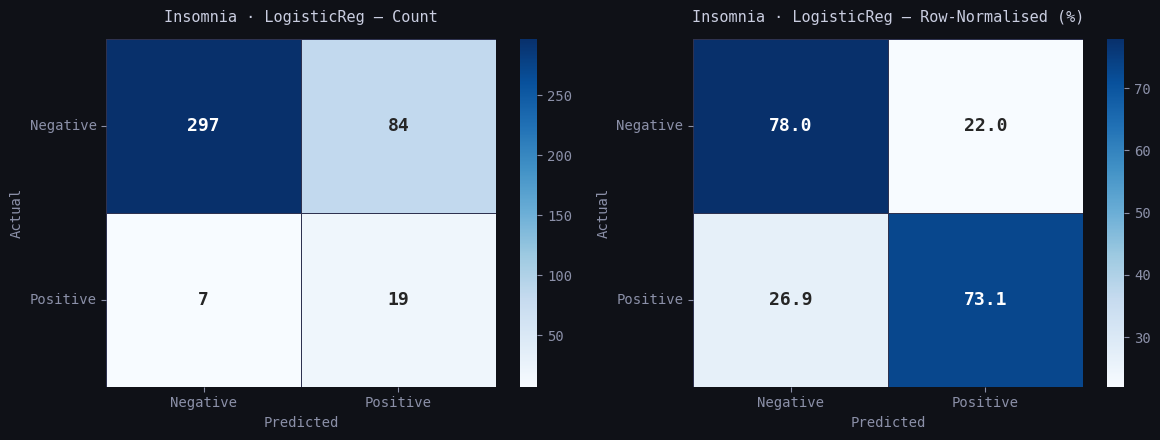

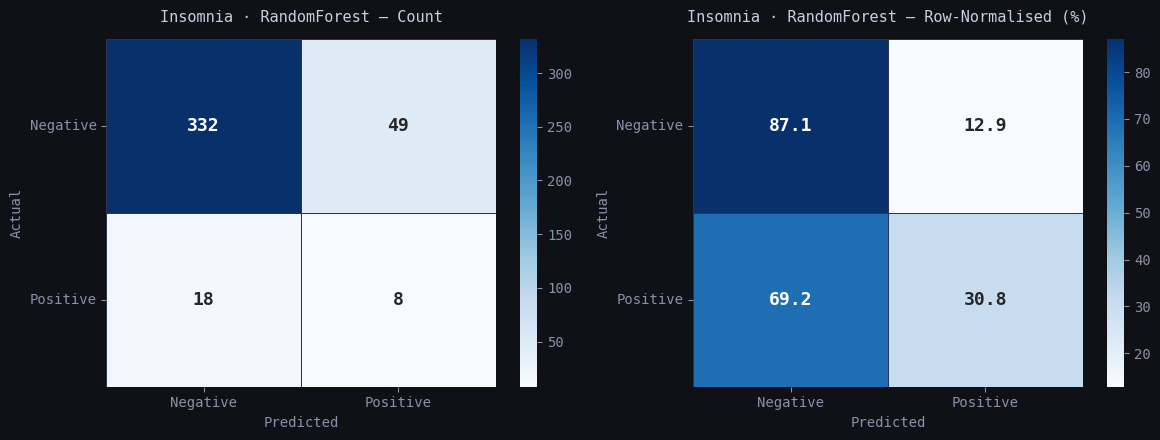

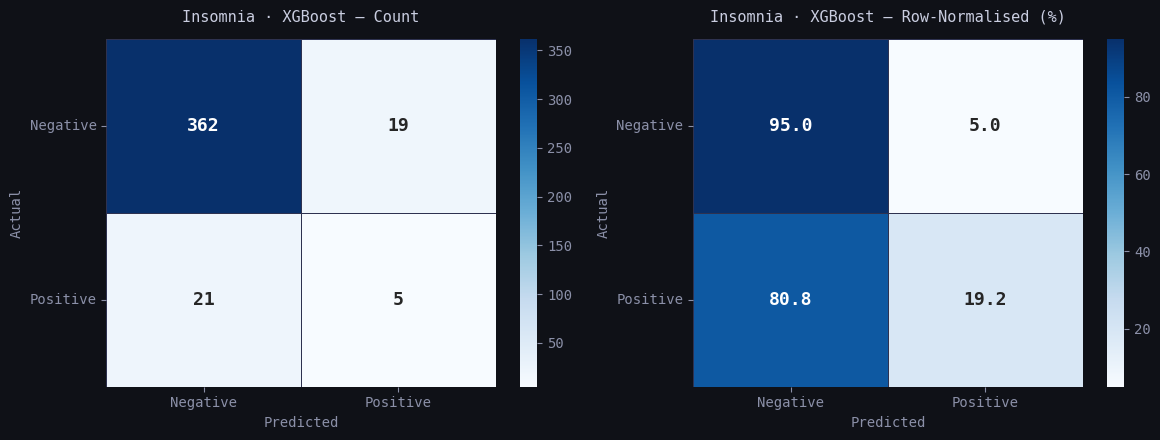

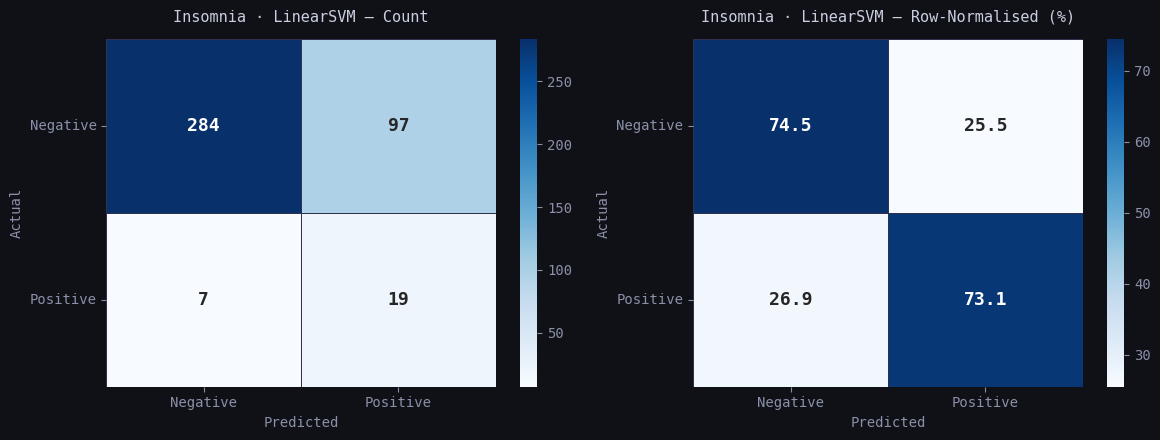

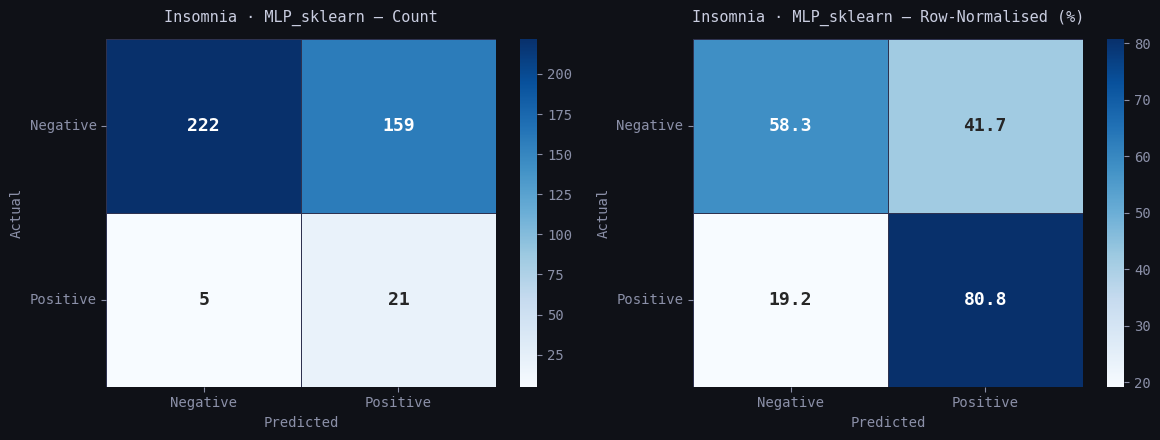

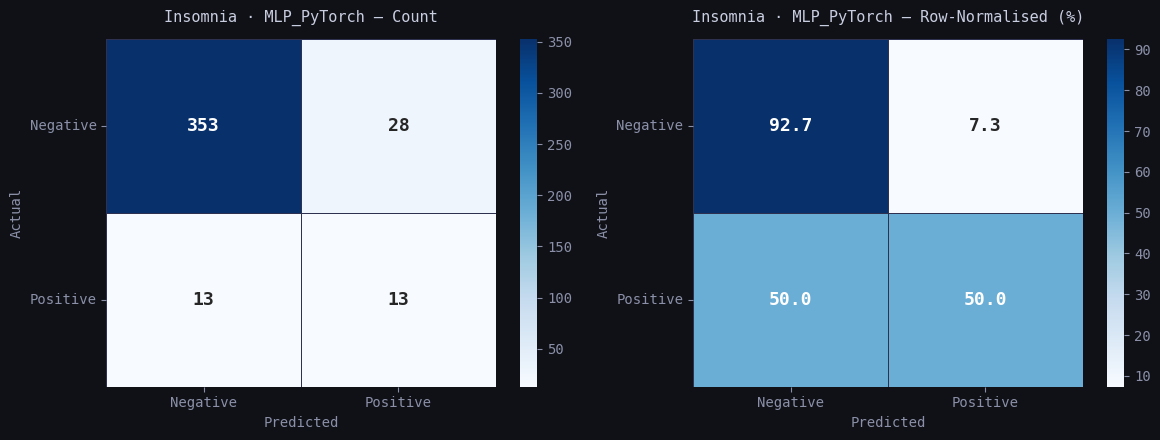


[6/6] ROC & PR Curves — Insomnia


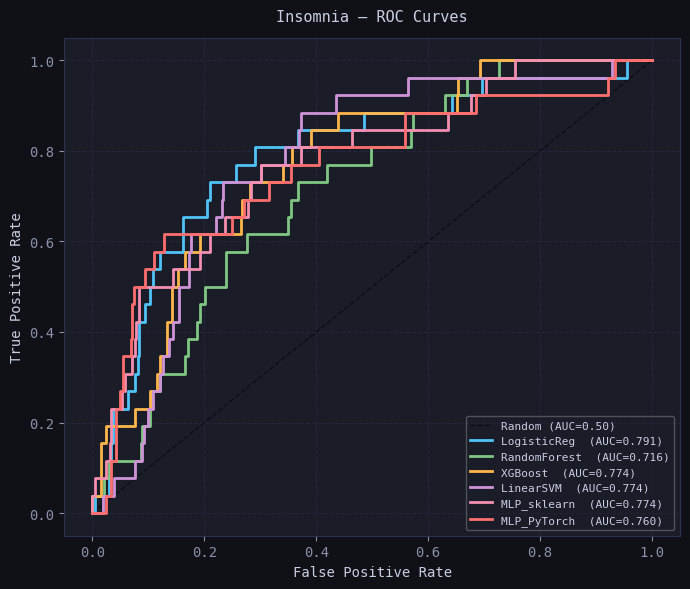

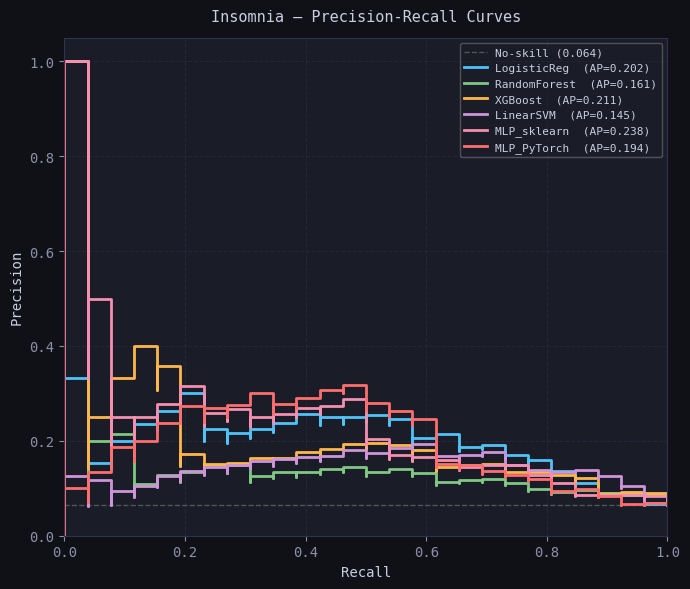


[+] Learning Curves — Insomnia


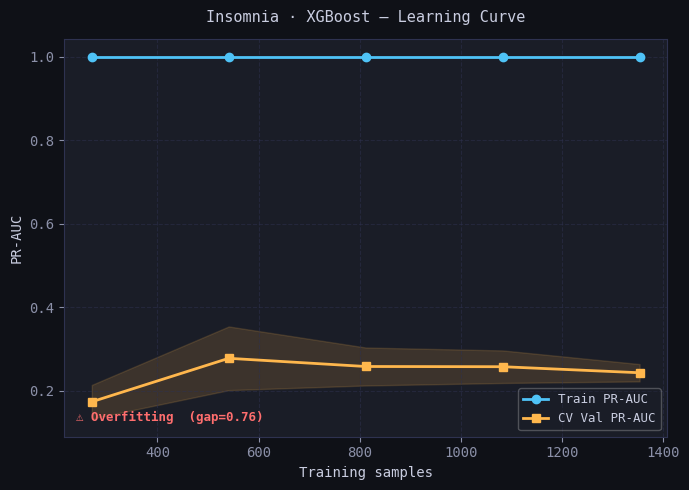

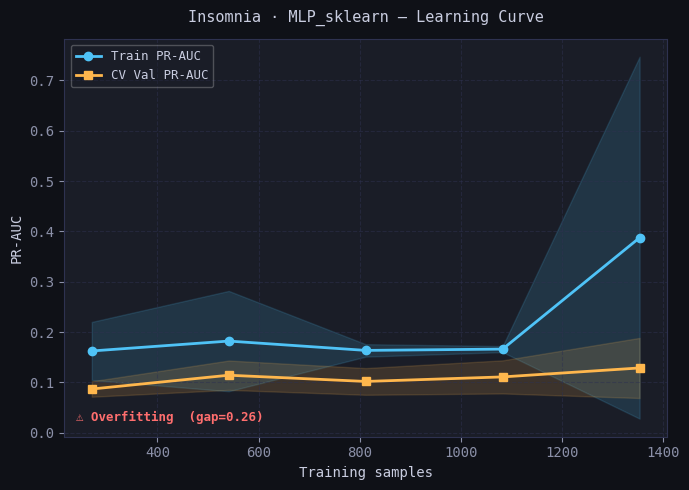


[+] PyTorch Training Curves — Insomnia


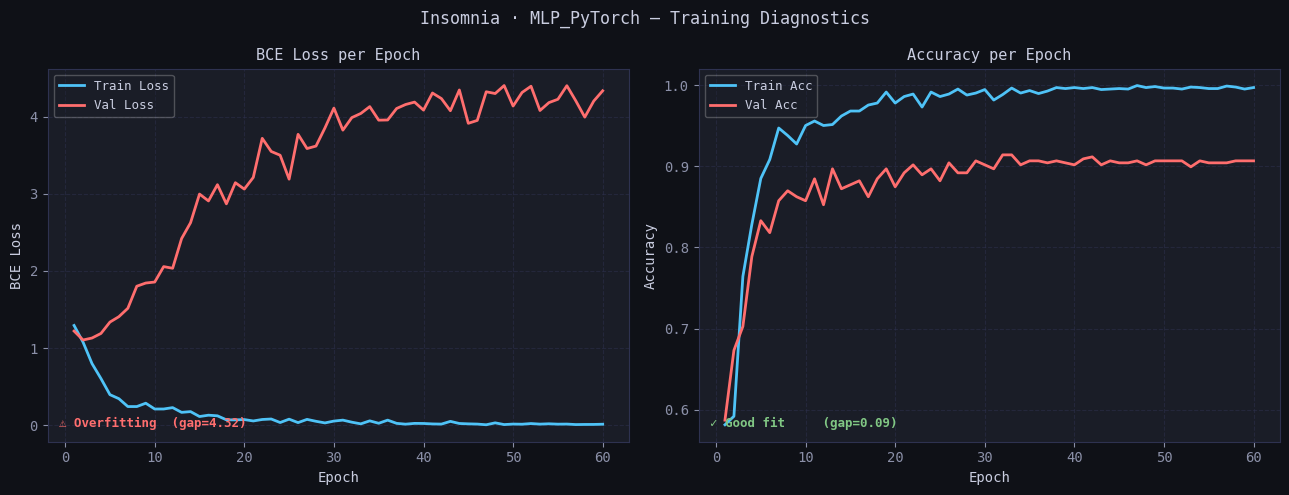


  ⏱ Insomnia total: 13.1 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  RLS (rstlesslgs5)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features: 622  |  Samples: 2025
  Class balance: {0.0: np.int64(1933), 1.0: np.int64(92)}

[2/6] Stability Selection...
  → Stability selection: 30 bootstraps, fixed C=0.1
    Bootstrap 10/30  (293s elapsed)
    Bootstrap 20/30  (579s elapsed)
    Bootstrap 30/30  (900s elapsed)
  → 371 stable features in 900s
  Selected features: [np.str_('mesaid'), np.str_('gender1'), np.str_('cucmcn1c'), np.str_('sleepage5c'), np.str_('htcm5'), np.str_('bmi5c'), np.str_('smkstat5'), np.str_('cursmk5'), np.str_('bedtmwkday5c'), np.str_('wkdaysleepdur5c'), np.str_('wkdaysleepdur5t'), np.str_('bedtmwkend5c'), np.str_('wkendsleepdur5t'), np.str_('nap5'), np.str_('trbleslpng5'), np.str_('bcksleep5'), np.str_('slpngpills5'), np.str_('irritable5'), np.str_('typicalslp5'), np.str_('readng5'), np.str

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


F1=0.097  AUROC=0.551  AP=0.060  (66s)
  ► RandomForest... F1=0.115  AUROC=0.686  AP=0.099  (4s)
  ► XGBoost... F1=0.109  AUROC=0.698  AP=0.093  (5s)
  ► LinearSVM... F1=0.078  AUROC=0.487  AP=0.053  (3s)
  ► MLP_sklearn... F1=0.000  AUROC=0.585  AP=0.064  (1s)

  ► MLP_PyTorch (60 epochs)...
    Epoch [20/60]  Train loss=0.0792 acc=0.9796  Val loss=4.0587 acc=0.8815
    Epoch [40/60]  Train loss=0.0146 acc=0.9963  Val loss=5.6413 acc=0.9136
    Epoch [60/60]  Train loss=0.0522 acc=0.9963  Val loss=5.6518 acc=0.9111
  F1=0.155  AUROC=0.631  AP=0.093  (5s)

[4/6] Classification Reports — RLS

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9594    0.7933    0.8685       387
    Positive     0.0588    0.2778    0.0971        18

    accuracy                         0.7704       405
   macro avg     0.5091    0.5355    0.4828       405
weighted avg     0.9194    0.7704    0.8342       405


  ▸ RandomForest
              precision    recall  f1-sc

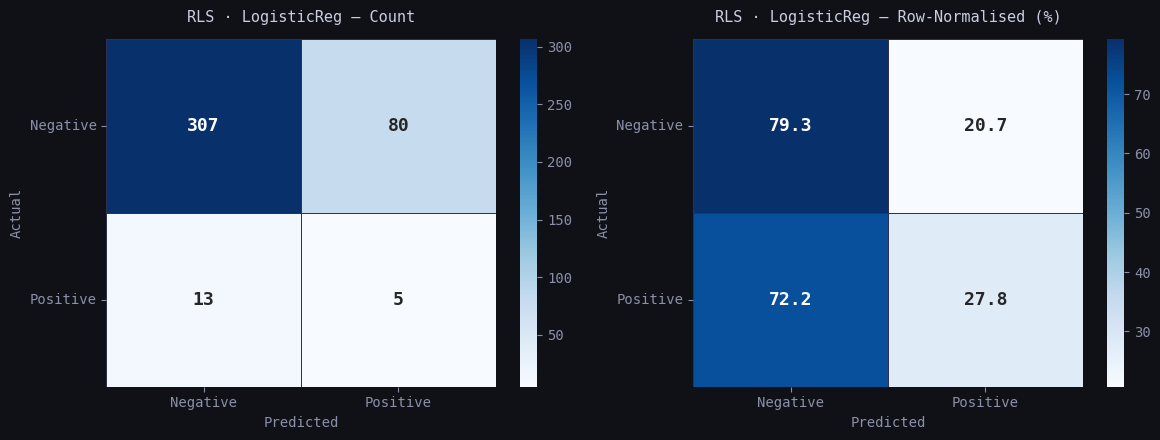

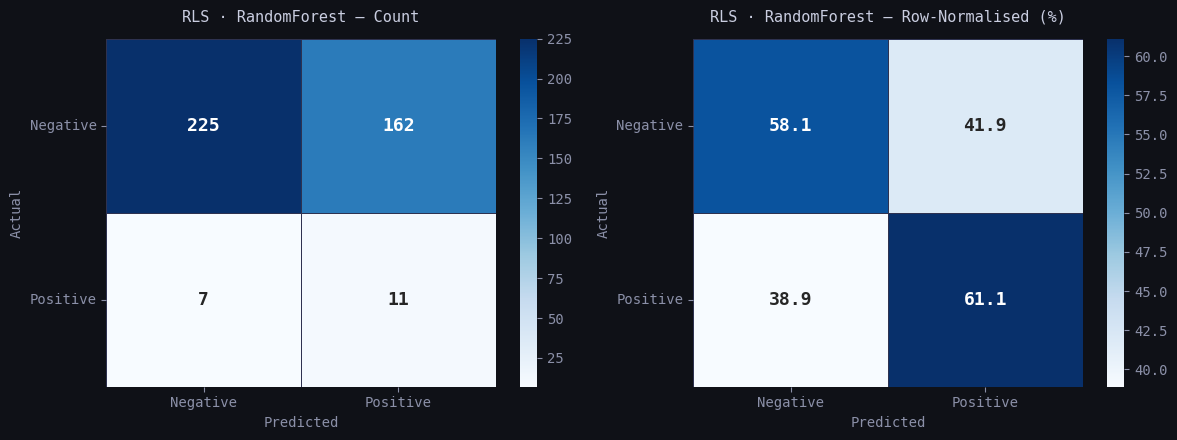

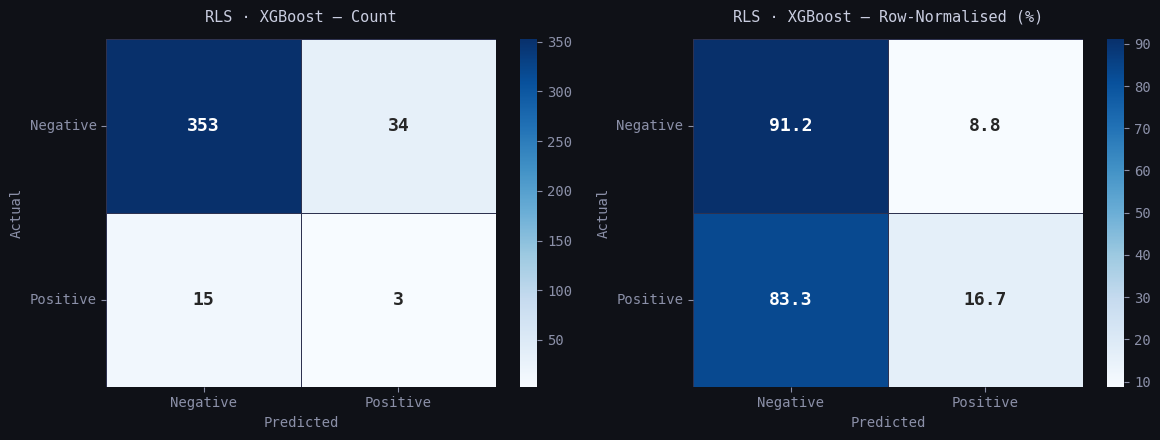

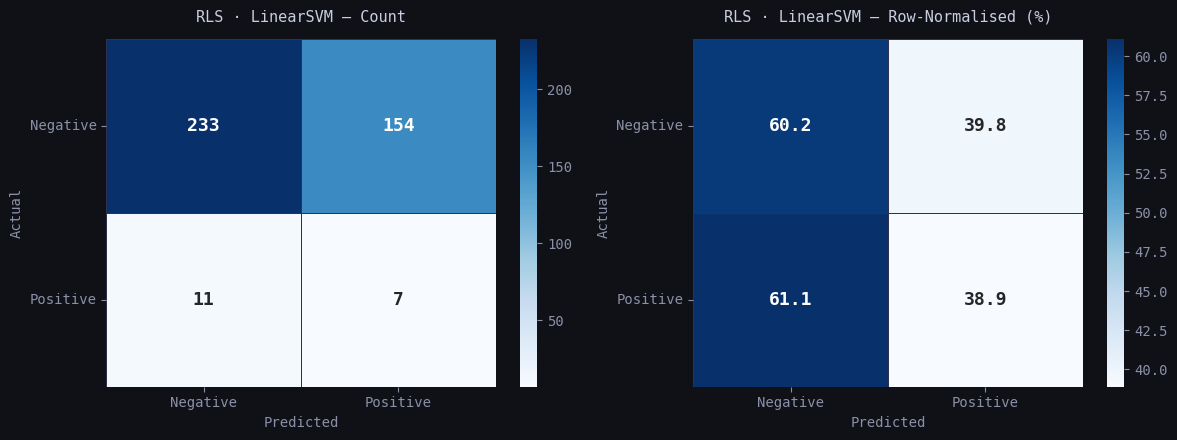

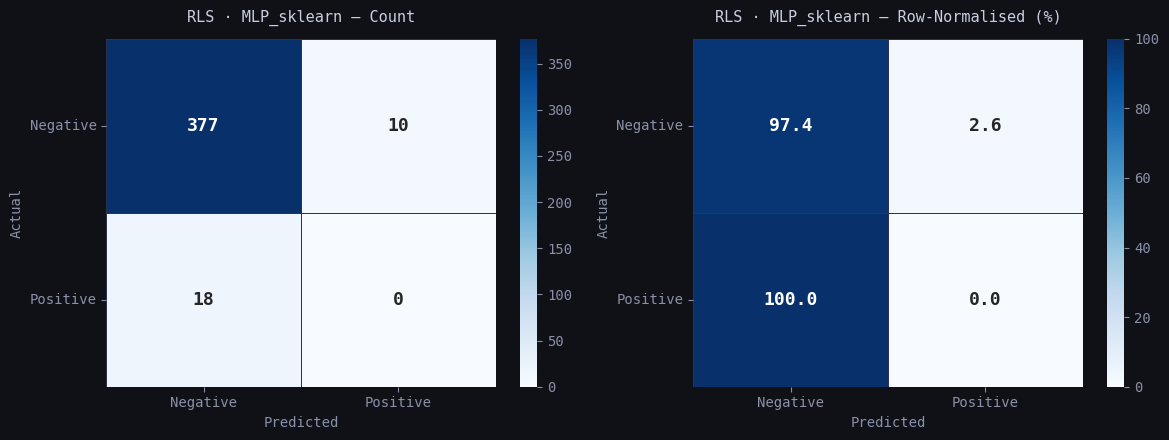

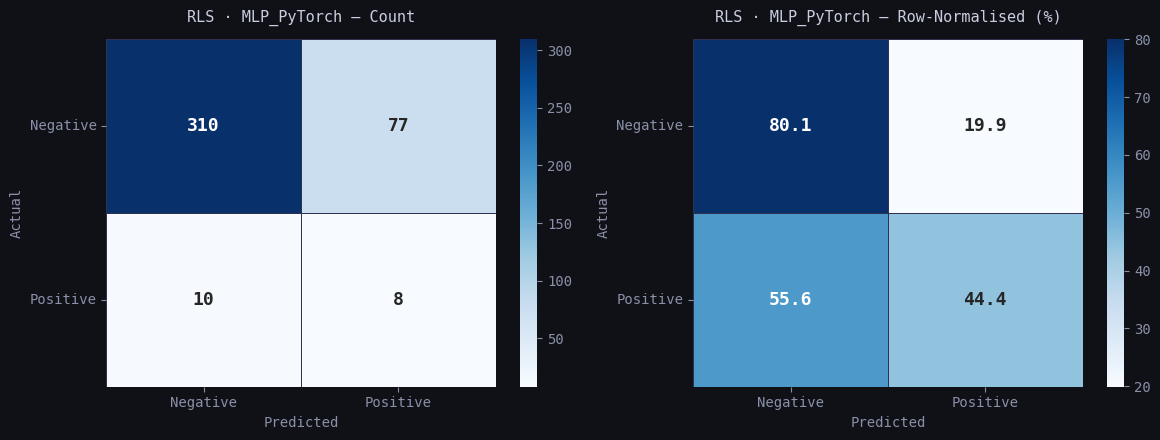


[6/6] ROC & PR Curves — RLS


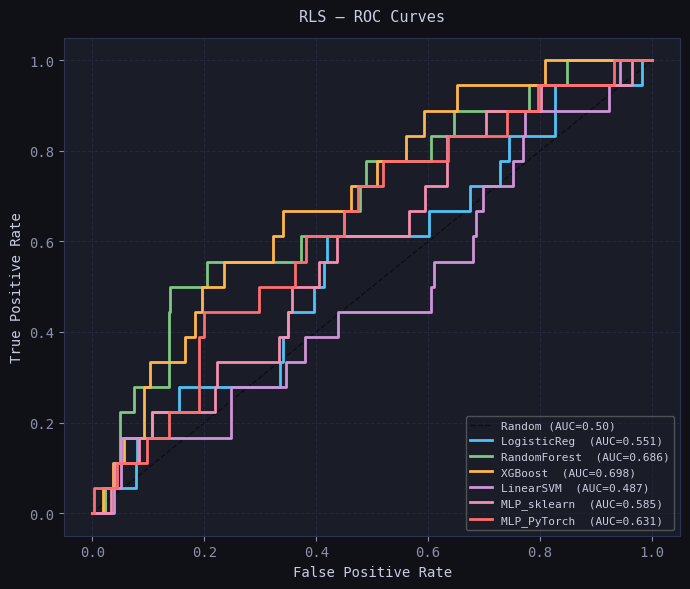

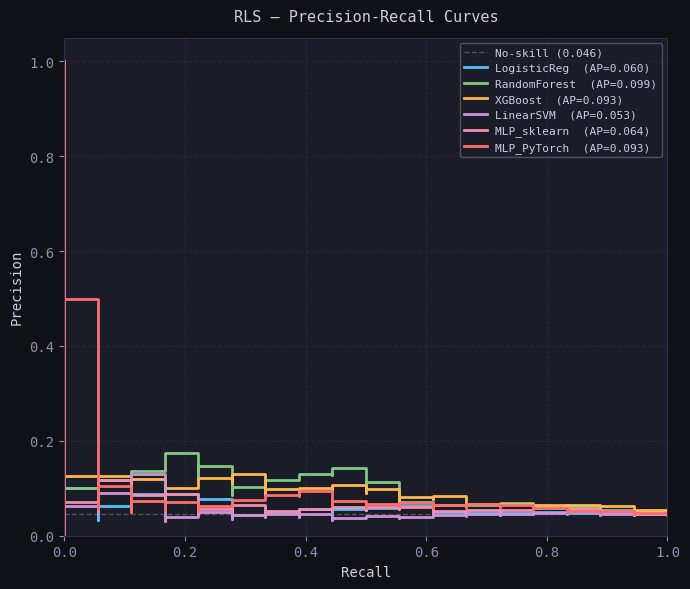


[+] Learning Curves — RLS


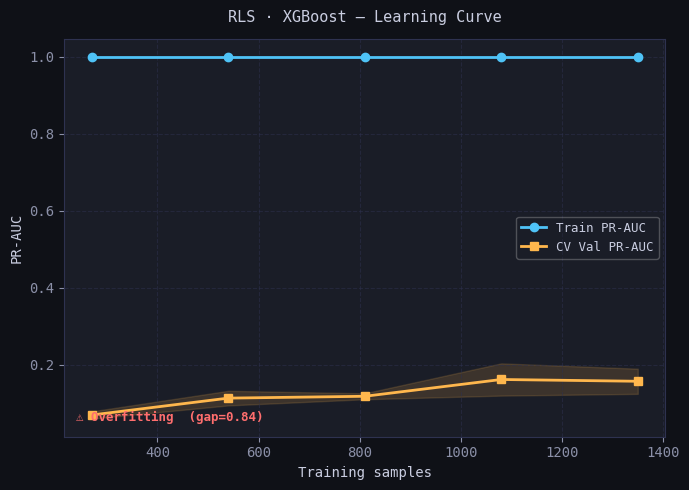

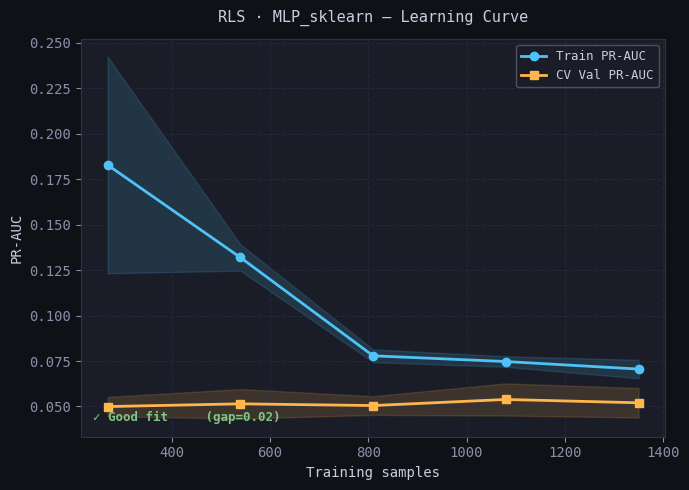


[+] PyTorch Training Curves — RLS


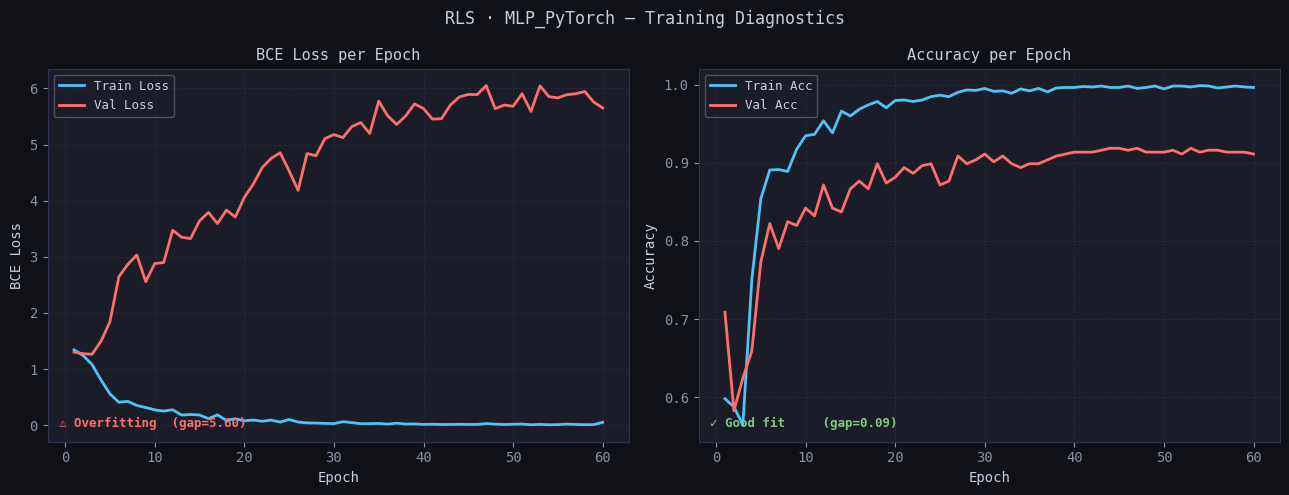


  ⏱ RLS total: 16.7 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  APNEA (slpapnea5)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features: 622  |  Samples: 2037
  Class balance: {0.0: np.int64(1881), 1.0: np.int64(156)}

[2/6] Stability Selection...
  → Stability selection: 30 bootstraps, fixed C=0.1
    Bootstrap 10/30  (158s elapsed)
    Bootstrap 20/30  (313s elapsed)
    Bootstrap 30/30  (464s elapsed)
  → 326 stable features in 464s
  Selected features: [np.str_('mesaid'), np.str_('race1c'), np.str_('gender1'), np.str_('sleepage5c'), np.str_('wtlb5'), np.str_('bmi5c'), np.str_('smkstat5'), np.str_('waketmwkday5c'), np.str_('wkdaysleepdur5t'), np.str_('bedtmwkend5c'), np.str_('wkendsleepdur5t'), np.str_('nap5'), np.str_('trbleslpng5'), np.str_('wakeup5'), np.str_('wakeearly5'), np.str_('sleepy5'), np.str_('tv5'), np.str_('riding5'), np.str_('lyngdwn5'), np.str_('talkng5'), np.str_('dinner5'), np.str_('dri

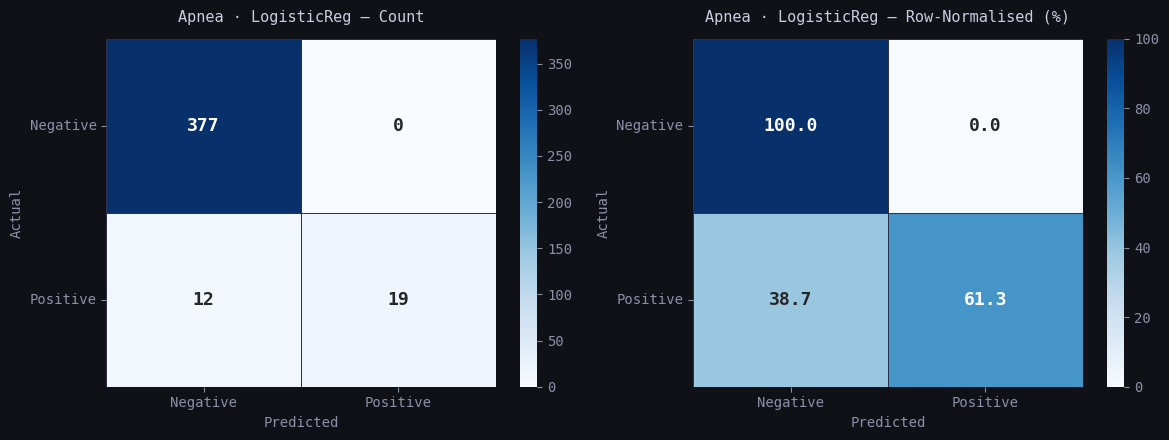

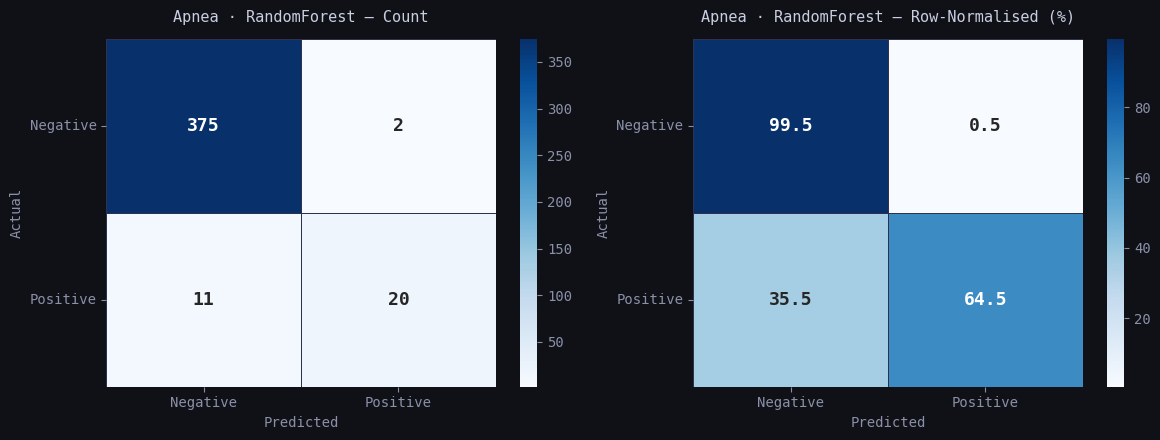

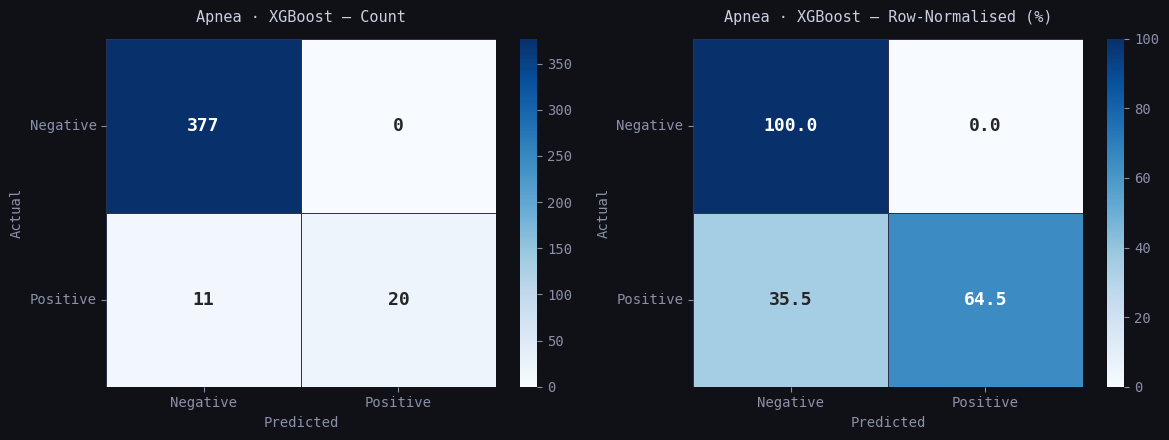

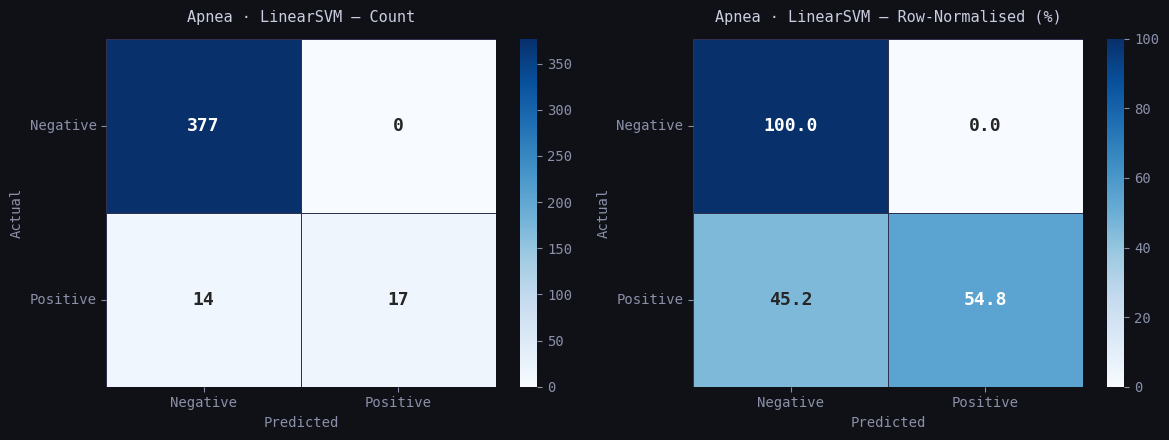

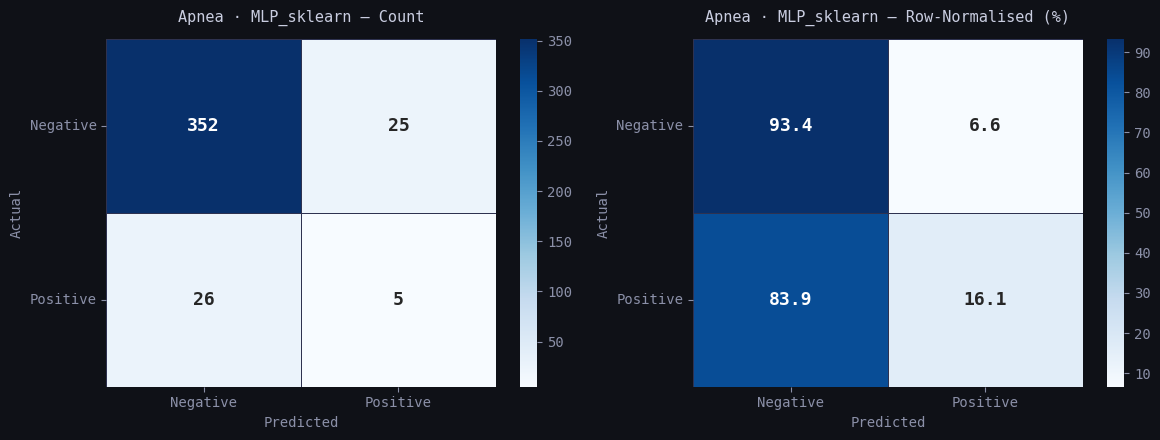

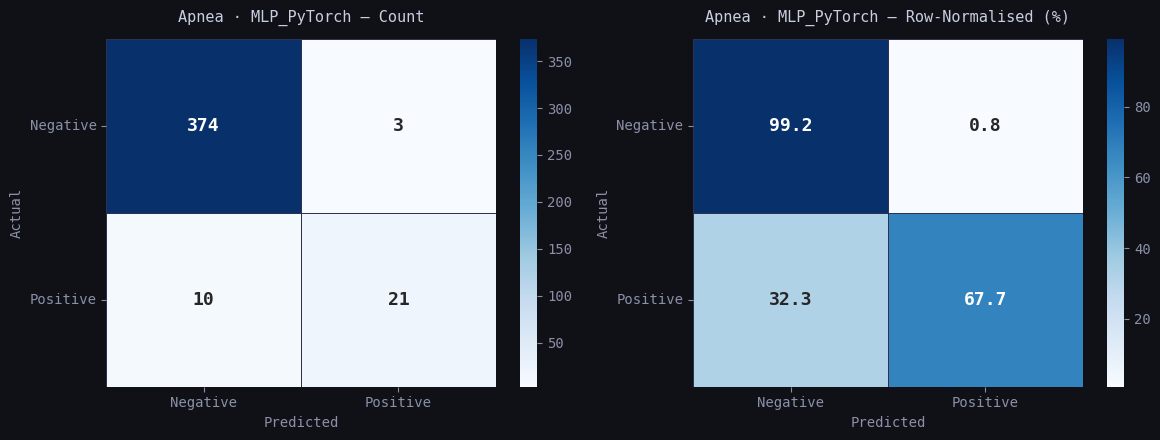


[6/6] ROC & PR Curves — Apnea


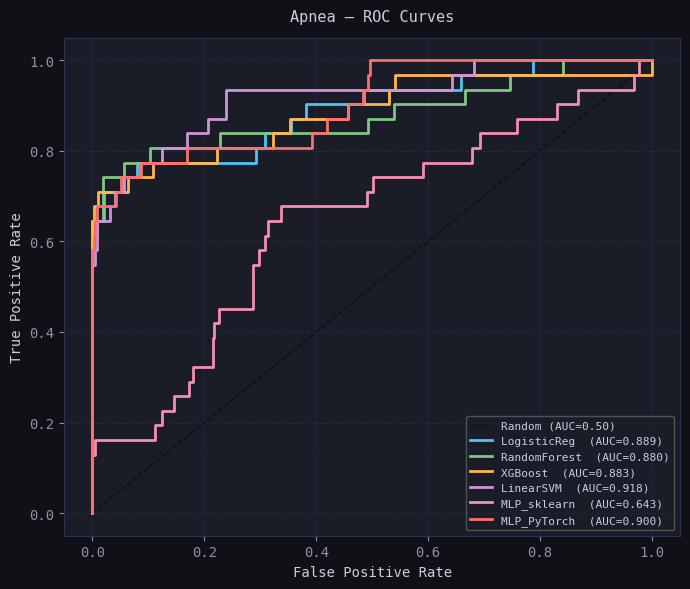

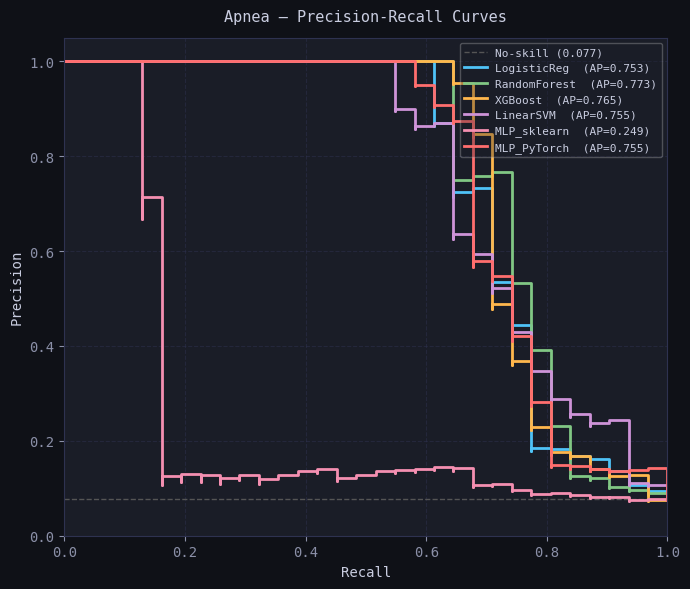


[+] Learning Curves — Apnea


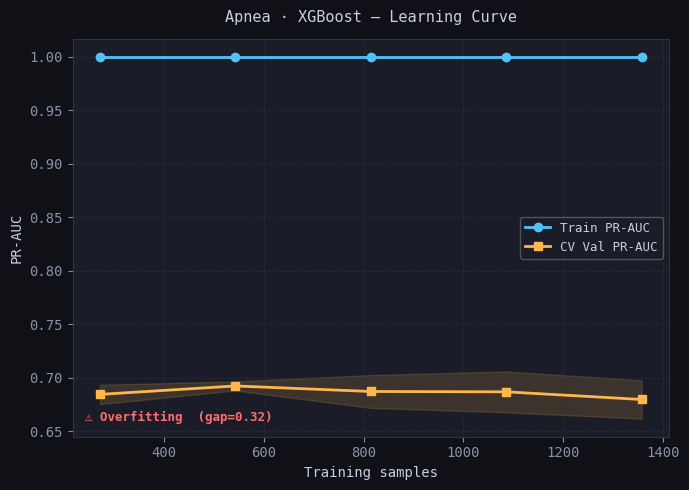

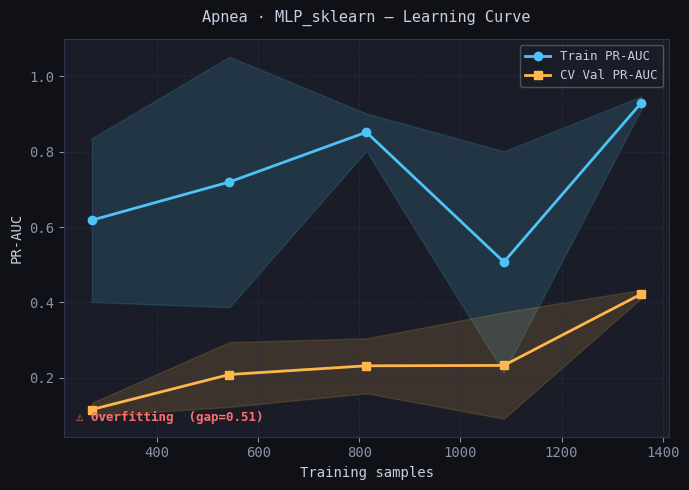


[+] PyTorch Training Curves — Apnea


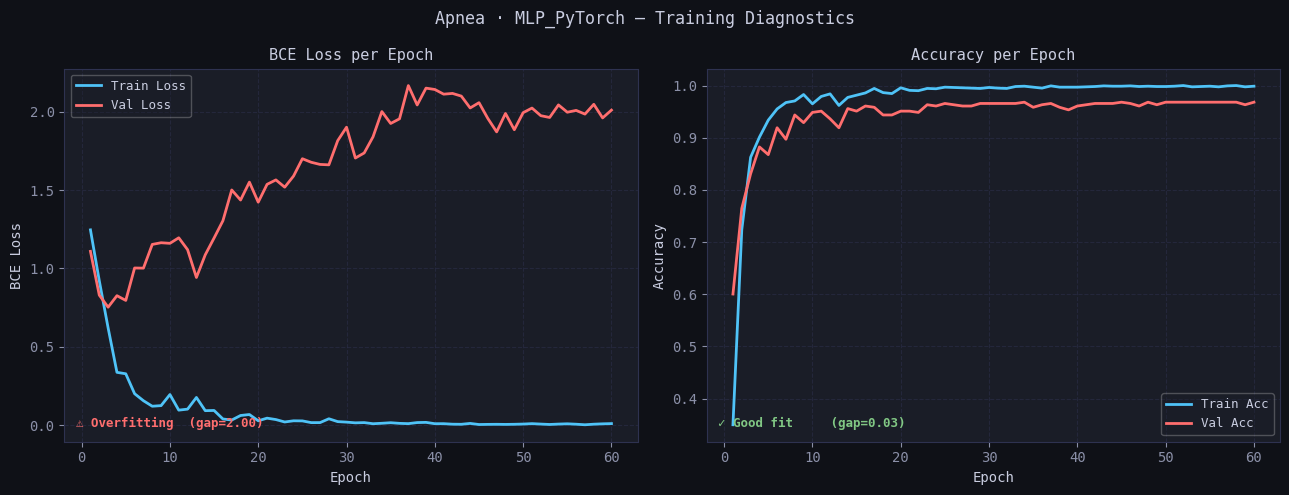


  ⏱ Apnea total: 8.4 min


  🏁 ALL TARGETS DONE in 38.2 min


In [26]:
all_results = {}
overall_t0  = time.time()

for target in TARGET_COLUMNS:
    label = TARGET_LABELS[target]
    t_start = time.time()

    print()
    print('▓' * 65)
    print(f'  🎯  {label.upper()} ({target})')
    print('▓' * 65)

    # ── Preprocessing ────────────────────────────────────────────────────
    print('\n[1/6] Preprocessing...')
    y = df[target]
    X = df.drop(columns=TARGET_COLUMNS)
    X = preprocess_non_numeric(X)
    X, y = drop_nan_targets(X, y)
    X, y = drop_bad_rows(X, y)
    X_scaled, feature_names = impute_and_scale(X)
    print(f'  Features: {len(feature_names)}  |  Samples: {len(y)}')
    print(f'  Class balance: {dict(pd.Series(y.values).value_counts())}')

    # ── Stability Selection ──────────────────────────────────────────────
    print('\n[2/6] Stability Selection...')
    stable = stability_selection_elasticnet(X_scaled, y, feature_names)
    X_final = X_scaled[:, [feature_names.index(f) for f in stable]]
    print(f'  Selected features: {stable}')
    pd.Series(stable).to_csv(f'/kaggle/working/{target}_stable_features.csv', index=False)

    # Fallback: if stability selected 0 features, use top 20 by variance
    if X_final.shape[1] == 0:
        print('  ⚠ No stable features found — falling back to top-20 by variance')
        var_idx = np.argsort(X_scaled.var(axis=0))[::-1][:20]
        X_final = X_scaled[:, var_idx]
        stable  = [feature_names[i] for i in var_idx]

    # ── Train / Test Split ───────────────────────────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_final, y, test_size=TEST_SIZE,
        stratify=y, random_state=RANDOM_STATE
    )
    baseline_rate = float(y_tr.mean())
    neg_count     = (y_tr == 0).sum()
    pos_count     = (y_tr == 1).sum()
    pos_weight    = neg_count / max(pos_count, 1)
    print(f'\n  Train={len(y_tr)}  Test={len(y_te)}  pos_rate={baseline_rate:.3f}  pos_weight={pos_weight:.1f}')

    # ── sklearn Models ───────────────────────────────────────────────────
    print('\n[3/6] Training sklearn models...')
    target_results = {}
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for mname, model in get_sklearn_models(pos_weight).items():
        t0 = time.time()
        print(f'  ► {mname}...', end=' ', flush=True)

        # OOF probs on train (for learning curve reference)
        oof_probs = cross_val_predict(model, X_tr, y_tr, cv=cv,
                                      method='predict_proba', n_jobs=-1)[:, 1]
        # Fit on full train → predict test
        model.fit(X_tr, y_tr)
        test_probs = model.predict_proba(X_te)[:, 1]
        thr        = tune_threshold(y_tr, oof_probs)
        test_preds = (test_probs >= thr).astype(int)

        f1    = f1_score(y_te, test_preds, zero_division=0)
        auroc = roc_auc_score(y_te, test_probs)
        ap    = average_precision_score(y_te, test_probs)
        print(f'F1={f1:.3f}  AUROC={auroc:.3f}  AP={ap:.3f}  ({time.time()-t0:.0f}s)')

        target_results[mname] = {
            'y_true': y_te, 'probs': test_probs, 'preds': test_preds,
            'model': model, 'oof_probs': oof_probs, 'y_tr': y_tr,
        }

    # ── PyTorch DeepMLP ──────────────────────────────────────────────────
    print(f'\n  ► MLP_PyTorch ({DL_EPOCHS} epochs)...')
    t0 = time.time()
    dl_model, tr_l, vl_l, tr_a, vl_a = train_deep_mlp(X_tr, y_tr, X_te, y_te)
    dl_probs = dl_predict_proba(dl_model, X_te)
    dl_thr   = tune_threshold(y_te, dl_probs)
    dl_preds = (dl_probs >= dl_thr).astype(int)
    dl_f1    = f1_score(y_te, dl_preds, zero_division=0)
    dl_auroc = roc_auc_score(y_te, dl_probs)
    dl_ap    = average_precision_score(y_te, dl_probs)
    print(f'  F1={dl_f1:.3f}  AUROC={dl_auroc:.3f}  AP={dl_ap:.3f}  ({time.time()-t0:.0f}s)')

    target_results['MLP_PyTorch'] = {
        'y_true': y_te, 'probs': dl_probs, 'preds': dl_preds,
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs': tr_a,   'val_accs': vl_a,
    }
    all_results[target] = target_results

    # ── Classification Reports ───────────────────────────────────────────
    print(f'\n[4/6] Classification Reports — {label}')
    for mname, res in target_results.items():
        print(f'\n  ▸ {mname}')
        print(classification_report(
            res['y_true'], res['preds'],
            target_names=['Negative', 'Positive'],
            digits=4, zero_division=0
        ))

    # ── Confusion Matrices ───────────────────────────────────────────────
    print(f'\n[5/6] Confusion Matrices — {label}')
    for mname, res in target_results.items():
        plot_confusion_matrices(res['y_true'], res['preds'], f'{label} · {mname}')

    # ── ROC + PR ─────────────────────────────────────────────────────────
    print(f'\n[6/6] ROC & PR Curves — {label}')
    plot_roc_curves(target_results, label)
    plot_pr_curves(target_results, label, baseline_rate)

    # ── Learning Curves (sklearn: only 2 most important models) ──────────
    print(f'\n[+] Learning Curves — {label}')
    for mname in ['XGBoost', 'MLP_sklearn']:
        plot_learning_curves_sklearn(
            target_results[mname]['model'], X_final, y, mname, label
        )

    # ── DL Epoch Curves ──────────────────────────────────────────────────
    print(f'\n[+] PyTorch Training Curves — {label}')
    plot_dl_curves(tr_l, vl_l, tr_a, vl_a, label)

    print(f'\n  ⏱ {label} total: {(time.time()-t_start)/60:.1f} min')

print(f'\n\n  🏁 ALL TARGETS DONE in {(time.time()-overall_t0)/60:.1f} min')

## 10. Global Summary

In [27]:
rows = []
for target, res_dict in all_results.items():
    for mname, res in res_dict.items():
        rows.append({
            'Target' : TARGET_LABELS[target],
            'Model'  : mname,
            'F1'     : round(f1_score(res['y_true'], res['preds'], zero_division=0), 4),
            'AUROC'  : round(roc_auc_score(res['y_true'], res['probs']), 4),
            'PR-AUC' : round(average_precision_score(res['y_true'], res['probs']), 4),
        })

summary = pd.DataFrame(rows).sort_values(['Target', 'F1'], ascending=[True, False])
display(summary)
summary.to_csv('/kaggle/working/experiment3_summary.csv', index=False)

print('\n🏆 BEST MODEL PER TARGET')
display(summary.loc[summary.groupby('Target')['F1'].idxmax()])

print('\nPhase 2 baseline (L1-only):  Insomnia F1=0.2856  RLS F1=0.1656  Apnea F1=0.7822')

,Target,Model,F1,AUROC,PR-AUC
14,Apnea,XGBoost,0.7843,0.8835,0.7646
17,Apnea,MLP_PyTorch,0.7636,0.8998,0.7554
12,Apnea,LogisticReg,0.7600,0.8887,0.7530
13,Apnea,RandomForest,0.7547,0.8798,0.7732
15,Apnea,LinearSVM,0.7083,0.9182,0.7551
16,Apnea,MLP_sklearn,0.1639,0.6425,0.2491
5,Insomnia,MLP_PyTorch,0.3881,0.7597,0.1944
0,Insomnia,LogisticReg,0.2946,0.7914,0.2025
3,Insomnia,LinearSVM,0.2676,0.7737,0.1446
4,Insomnia,MLP_sklearn,0.2039,0.7736,0.2376



🏆 BEST MODEL PER TARGET


,Target,Model,F1,AUROC,PR-AUC
14,Apnea,XGBoost,0.7843,0.8835,0.7646
5,Insomnia,MLP_PyTorch,0.3881,0.7597,0.1944
11,RLS,MLP_PyTorch,0.1553,0.6308,0.0934



Phase 2 baseline (L1-only):  Insomnia F1=0.2856  RLS F1=0.1656  Apnea F1=0.7822
